# Comparações múltiplas

**Tema:** Estatística › Testes de Hipótese

Este é o problema que mais silenciosamente destrói a credibilidade de análises
de dados. Ele não produz erro de código, não gera aviso, não aparece em
nenhum log. Simplesmente faz você **encontrar coisas que não existem**.

> **Analogia — o atirador texano:** ele descarrega a espingarda na parede do
> celeiro e depois desenha o alvo em volta do maior aglomerado de furos. Depois
> exibe a foto como prova de pontaria. A regra de ouro da honestidade
> estatística é **desenhar o alvo antes de atirar**.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from statsmodels.stats.multitest import multipletests

rng = np.random.default_rng(9090)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3
AZUL, VERDE, VERMELHO, ROXO, AMBAR = "#1F5C8B", "#1E6B4F", "#9C2B2B", "#5B3E86", "#8A6100"
print("pronto")

pronto


## 1. A aritmética implacável

$$P(\text{pelo menos 1 falso positivo}) = 1 - (1 - \alpha)^m$$

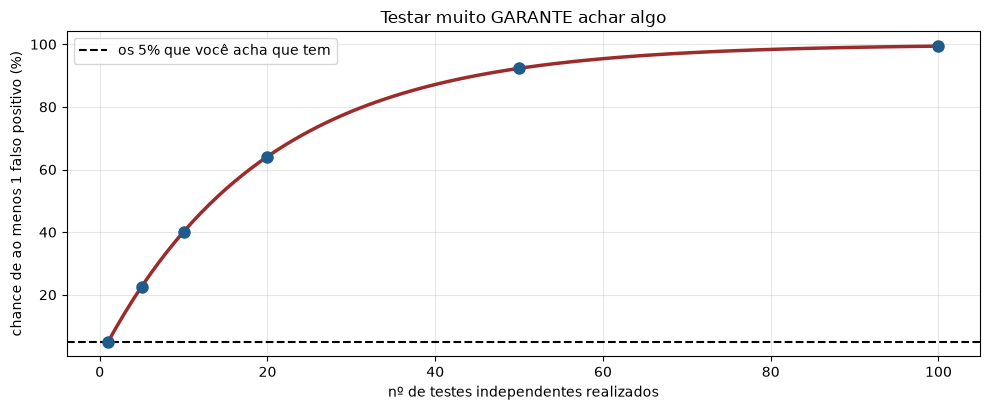

 nº de testes   P(≥1 falso positivo)
-------------------------------------
            1                  5.0%
            3                 14.3%
            5                 22.6%
           10                 40.1%
           14                 51.2%
           20                 64.2%
           50                 92.3%
          100                 99.4%

Com 14 testes, é mais provável ter um falso positivo do que não ter.


In [2]:
m = np.arange(1, 101)
fwer = 1 - (1 - 0.05) ** m

fig, ax = plt.subplots(figsize=(10, 4.2))
ax.plot(m, fwer * 100, lw=2.5, color=VERMELHO)
ax.axhline(5, ls="--", color="black", lw=1.5, label="os 5% que você acha que tem")
for k in [1, 5, 10, 20, 50, 100]:
    ax.plot(k, (1 - 0.95 ** k) * 100, "o", ms=8, color=AZUL)
ax.set_xlabel("nº de testes independentes realizados")
ax.set_ylabel("chance de ao menos 1 falso positivo (%)")
ax.set_title("Testar muito GARANTE achar algo")
ax.legend()
plt.tight_layout()
plt.show()

print(f"{'nº de testes':>13s} {'P(≥1 falso positivo)':>22s}")
print("-" * 37)
for k in [1, 3, 5, 10, 14, 20, 50, 100]:
    print(f"{k:>13d} {1 - 0.95**k:>21.1%}")
print("\nCom 14 testes, é mais provável ter um falso positivo do que não ter.")

## 2. O experimento que demonstra o problema

Vamos rodar um A/B **sem nenhum efeito**, mas analisar 20 métricas e 15
segmentos — exatamente o que acontece na prática quando o resultado principal
"não deu nada" e alguém pede para "olhar melhor".

In [3]:
def experimento_sem_efeito(n_por_grupo=5_000, n_metricas=20, n_segmentos=15,
                           semente=0):
    """A/B em que os dois grupos vêm da MESMA distribuição. Nada é real."""
    r = np.random.default_rng(semente)
    achados = []

    # (a) várias métricas na base inteira
    for k in range(n_metricas):
        a = r.normal(0, 1, n_por_grupo)
        b = r.normal(0, 1, n_por_grupo)
        p = stats.ttest_ind(a, b, equal_var=False).pvalue
        achados.append({"tipo": "métrica", "nome": f"métrica_{k+1}", "p": p})

    # (b) a métrica principal, fatiada por segmentos
    for k in range(n_segmentos):
        n_seg = n_por_grupo // n_segmentos
        a = r.normal(0, 1, n_seg)
        b = r.normal(0, 1, n_seg)
        p = stats.ttest_ind(a, b, equal_var=False).pvalue
        achados.append({"tipo": "segmento", "nome": f"segmento_{k+1}", "p": p})

    return pd.DataFrame(achados)


achados = experimento_sem_efeito(semente=11)
significativos = achados[achados["p"] < 0.05]

print(f"Testes realizados: {len(achados)}")
print(f"'Descobertas' com p < 0,05: {len(significativos)}")
print("\nE lembre: NÃO EXISTE EFEITO NENHUM nestes dados.\n")
print(significativos.sort_values("p").to_string(index=False,
      float_format=lambda x: f"{x:.4f}"))

Testes realizados: 35
'Descobertas' com p < 0,05: 0

E lembre: NÃO EXISTE EFEITO NENHUM nestes dados.

Empty DataFrame
Columns: [tipo, nome, p]
Index: []


> **O relatório que sairia dessa análise:** *"O teste não mostrou efeito na
> métrica principal, mas identificamos um ganho significativo no segmento X
> (p = 0,01) e na métrica Y (p = 0,03). Recomendamos aprofundar."*
>
> Tudo falso. E o relatório está tecnicamente correto em cada número que
> reporta — o que o torna especialmente perigoso.

## 3. Quantos falsos positivos, na média?

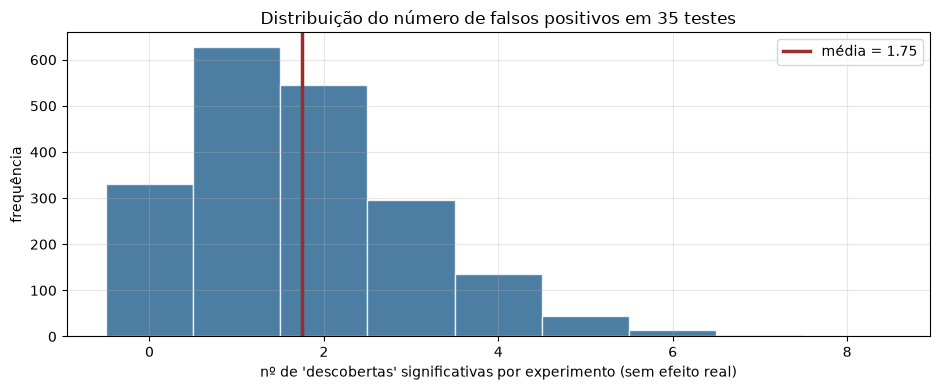

Média de falsos positivos por experimento: 1.75
Esperado teoricamente (35 × 0,05):         1.75
Experimentos com ao menos 1 'descoberta':  83.5%
Experimentos com 3 ou mais:                24.9%


In [4]:
N_REPLICAS = 2_000
contagens = []
for s in range(N_REPLICAS):
    a = experimento_sem_efeito(n_por_grupo=2_000, semente=1000 + s)
    contagens.append((a["p"] < 0.05).sum())
contagens = np.array(contagens)

fig, ax = plt.subplots(figsize=(9.5, 4))
ax.hist(contagens, bins=np.arange(-0.5, contagens.max() + 1.5),
        color=AZUL, alpha=0.8, edgecolor="white")
ax.axvline(contagens.mean(), color=VERMELHO, lw=2.5,
           label=f"média = {contagens.mean():.2f}")
ax.set_xlabel("nº de 'descobertas' significativas por experimento (sem efeito real)")
ax.set_ylabel("frequência")
ax.set_title("Distribuição do número de falsos positivos em 35 testes")
ax.legend()
plt.tight_layout()
plt.show()

print(f"Média de falsos positivos por experimento: {contagens.mean():.2f}")
print(f"Esperado teoricamente (35 × 0,05):         {35*0.05:.2f}")
print(f"Experimentos com ao menos 1 'descoberta':  {(contagens > 0).mean():.1%}")
print(f"Experimentos com 3 ou mais:                {(contagens >= 3).mean():.1%}")

## 4. As correções: FWER e FDR

Duas filosofias diferentes:

* **FWER** (*family-wise error rate*) — controla a probabilidade de cometer
  **qualquer** falso positivo. Rigoroso. Use em decisões confirmatórias.
* **FDR** (*false discovery rate*) — controla a **proporção esperada** de
  falsos positivos entre as descobertas. Mais permissivo. Use em triagem
  exploratória de muitas hipóteses.

In [5]:
def cenario_misto(n_verdadeiros=10, n_nulos=90, efeito=0.45, n=200, semente=0):
    """Alguns efeitos REAIS misturados a muitas hipóteses nulas."""
    r = np.random.default_rng(semente)
    p_valores, e_real = [], []
    for k in range(n_verdadeiros + n_nulos):
        real = k < n_verdadeiros
        a = r.normal(0, 1, n)
        b = r.normal(efeito if real else 0.0, 1, n)
        p_valores.append(stats.ttest_ind(b, a, equal_var=False).pvalue)
        e_real.append(real)
    return np.array(p_valores), np.array(e_real)


p_vals, verdadeiros = cenario_misto(semente=7)

metodos = {
    "Sem correção": ("none", None),
    "Bonferroni (FWER)": ("bonferroni", None),
    "Holm (FWER)": ("holm", None),
    "Benjamini-Hochberg (FDR)": ("fdr_bh", None),
}

print(f"Cenário: {verdadeiros.sum()} efeitos REAIS em "
      f"{len(verdadeiros)} hipóteses testadas\n")
print(f"{'método':28s} {'descobertas':>12s} {'verdadeiras':>12s} "
      f"{'falsas':>8s} {'poder':>8s} {'FDR real':>10s}")
print("-" * 84)
linhas_resultado = []
for nome, (metodo, _) in metodos.items():
    if metodo == "none":
        rejeita = p_vals < 0.05
    else:
        rejeita, _, _, _ = multipletests(p_vals, alpha=0.05, method=metodo)
    vp = (rejeita & verdadeiros).sum()
    fp = (rejeita & ~verdadeiros).sum()
    poder = vp / verdadeiros.sum()
    fdr = fp / max(rejeita.sum(), 1)
    linhas_resultado.append({"método": nome, "poder": poder, "FDR": fdr,
                             "VP": vp, "FP": fp})
    print(f"{nome:28s} {rejeita.sum():>12d} {vp:>12d} {fp:>8d} "
          f"{poder:>7.1%} {fdr:>9.1%}")

Cenário: 10 efeitos REAIS em 100 hipóteses testadas

método                        descobertas  verdadeiras   falsas    poder   FDR real
------------------------------------------------------------------------------------
Sem correção                           15           10        5  100.0%     33.3%
Bonferroni (FWER)                       9            9        0   90.0%      0.0%
Holm (FWER)                             9            9        0   90.0%      0.0%
Benjamini-Hochberg (FDR)               11           10        1  100.0%      9.1%


Uma execução única é anedota. Vamos repetir 400 vezes e medir o comportamento
médio de cada método.

Médias sobre 400 experimentos simulados

                          poder médio  FDR médio  P(algum falso positivo)
Sem correção                   0.9948     0.2979                   0.9925
Bonferroni (FWER)              0.8400     0.0079                   0.0700
Holm (FWER)                    0.8465     0.0079                   0.0700
Benjamini-Hochberg (FDR)       0.9533     0.0453                   0.4025


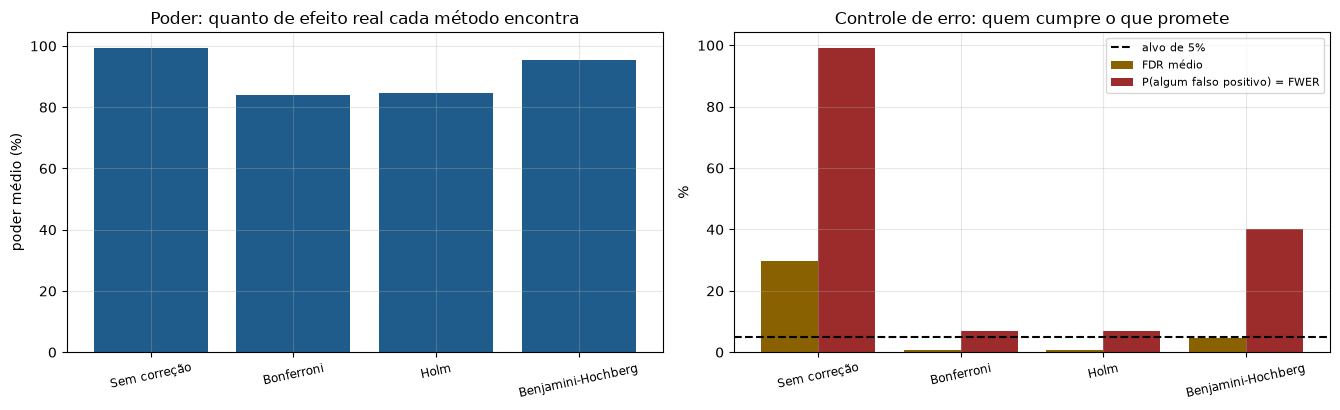

In [6]:
N_REP = 400
acumulado = {nome: {"poder": [], "fdr": [], "algum_fp": []} for nome in metodos}

for s in range(N_REP):
    p_vals, verd = cenario_misto(semente=5000 + s)
    for nome, (metodo, _) in metodos.items():
        if metodo == "none":
            rej = p_vals < 0.05
        else:
            rej, _, _, _ = multipletests(p_vals, alpha=0.05, method=metodo)
        vp = (rej & verd).sum()
        fp = (rej & ~verd).sum()
        acumulado[nome]["poder"].append(vp / verd.sum())
        acumulado[nome]["fdr"].append(fp / max(rej.sum(), 1))
        acumulado[nome]["algum_fp"].append(fp > 0)

resumo = pd.DataFrame({
    nome: {"poder médio": np.mean(v["poder"]),
           "FDR médio": np.mean(v["fdr"]),
           "P(algum falso positivo)": np.mean(v["algum_fp"])}
    for nome, v in acumulado.items()}).T
print(f"Médias sobre {N_REP} experimentos simulados\n")
print(resumo.round(4).to_string())

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13.5, 4.2))
x = np.arange(len(resumo))
ax1.bar(x, resumo["poder médio"] * 100, color=AZUL)
ax1.set_xticks(x)
ax1.set_xticklabels([n.split(" (")[0] for n in resumo.index], fontsize=8.5,
                    rotation=12)
ax1.set_ylabel("poder médio (%)")
ax1.set_title("Poder: quanto de efeito real cada método encontra")

ax2.bar(x - 0.2, resumo["FDR médio"] * 100, 0.4, color=AMBAR, label="FDR médio")
ax2.bar(x + 0.2, resumo["P(algum falso positivo)"] * 100, 0.4, color=VERMELHO,
        label="P(algum falso positivo) = FWER")
ax2.axhline(5, ls="--", color="black", lw=1.5, label="alvo de 5%")
ax2.set_xticks(x)
ax2.set_xticklabels([n.split(" (")[0] for n in resumo.index], fontsize=8.5,
                    rotation=12)
ax2.set_ylabel("%")
ax2.set_title("Controle de erro: quem cumpre o que promete")
ax2.legend(fontsize=8)
plt.tight_layout()
plt.show()

Leitura da tabela e dos gráficos:

* **Sem correção**: FDR bem acima de 5% e quase sempre há pelo menos um falso
  positivo. É o cenário do relatório mentiroso da seção 2.
* **Bonferroni e Holm**: mantêm a FWER em ~5% (a probabilidade de **qualquer**
  erro). Custo: poder menor.
* **Holm domina Bonferroni**: mesmo controle de FWER, poder estritamente maior.
  **Não há razão para usar Bonferroni em vez de Holm.**
* **Benjamini-Hochberg**: mantém o FDR em ~5% e tem poder bem maior. Em troca,
  admite que alguns dos achados serão falsos.

## 5. Como escolher, na prática

In [7]:
guia = pd.DataFrame([
    ("Teste A/B com UMA métrica principal pré-registrada",
     "Nenhuma correção", "Só há um teste confirmatório"),
    ("A/B com 3-5 métricas principais pré-registradas",
     "Holm (FWER)", "Decisão de negócio: qualquer falso positivo custa caro"),
    ("Análise por segmento pré-registrada (5-20 segmentos)",
     "Holm ou BH", "Depende de ser confirmatório ou exploratório"),
    ("Exploração de centenas de segmentos/features",
     "Benjamini-Hochberg (FDR)", "Triagem: alguns falsos são aceitáveis"),
    ("Seleção de features (milhares de variáveis)",
     "Benjamini-Hochberg (FDR)", "O objetivo é uma lista curta para investigar"),
    ("Ensaio clínico / decisão regulatória",
     "Bonferroni ou Holm", "Rigor máximo exigido pelo regulador"),
    ("Monitoramento contínuo de um experimento",
     "Fronteiras sequenciais", "O problema aqui é temporal, não de família"),
], columns=["Situação", "Correção recomendada", "Por quê"])
guia

,Situação,Correção recomendada,Por quê
0,Teste A/B com UMA métrica principal pré-regist...,Nenhuma correção,Só há um teste confirmatório
1,A/B com 3-5 métricas principais pré-registradas,Holm (FWER),Decisão de negócio: qualquer falso positivo cu...
2,Análise por segmento pré-registrada (5-20 segm...,Holm ou BH,Depende de ser confirmatório ou exploratório
3,Exploração de centenas de segmentos/features,Benjamini-Hochberg (FDR),Triagem: alguns falsos são aceitáveis
4,Seleção de features (milhares de variáveis),Benjamini-Hochberg (FDR),O objetivo é uma lista curta para investigar
5,Ensaio clínico / decisão regulatória,Bonferroni ou Holm,Rigor máximo exigido pelo regulador
6,Monitoramento contínuo de um experimento,Fronteiras sequenciais,"O problema aqui é temporal, não de família"


## 6. O caso especial e traiçoeiro: análise de subgrupos

Fatiar o resultado por segmento é a forma mais comum de p-hacking em produto —
e a mais difícil de detectar, porque cada análise individual parece legítima.

In [8]:
def relatorio_segmentos(n_segmentos=12, efeito_real=0.0, n_por_seg=800, semente=3):
    """Simula a análise por segmento de um A/B e aplica as correções."""
    r = np.random.default_rng(semente)
    nomes = [f"segmento_{i+1:02d}" for i in range(n_segmentos)]
    ps, efeitos = [], []
    for _ in range(n_segmentos):
        a = r.normal(0, 1, n_por_seg)
        b = r.normal(efeito_real, 1, n_por_seg)
        ps.append(stats.ttest_ind(b, a, equal_var=False).pvalue)
        efeitos.append(b.mean() - a.mean())
    ps = np.array(ps)

    rej_holm, p_holm, _, _ = multipletests(ps, alpha=0.05, method="holm")
    rej_bh, p_bh, _, _ = multipletests(ps, alpha=0.05, method="fdr_bh")

    return pd.DataFrame({
        "segmento": nomes, "efeito observado": efeitos, "p bruto": ps,
        "sig. bruto": np.where(ps < 0.05, "SIM", "—"),
        "p Holm": p_holm, "sig. Holm": np.where(rej_holm, "SIM", "—"),
        "p BH": p_bh, "sig. BH": np.where(rej_bh, "SIM", "—"),
    }).sort_values("p bruto")


print("CENÁRIO A — nenhum efeito real em nenhum segmento\n")
tab_a = relatorio_segmentos(efeito_real=0.0, semente=3)
print(tab_a.to_string(index=False, float_format=lambda x: f"{x:.4f}"))
print(f"\nsignificativos sem correção: {(tab_a['sig. bruto']=='SIM').sum()}"
      f"  |  com Holm: {(tab_a['sig. Holm']=='SIM').sum()}"
      f"  |  com BH: {(tab_a['sig. BH']=='SIM').sum()}")

print("\n" + "=" * 70)
print("CENÁRIO B — efeito real e homogêneo de 0,15 em TODOS os segmentos\n")
tab_b = relatorio_segmentos(efeito_real=0.15, semente=3)
print(tab_b.to_string(index=False, float_format=lambda x: f"{x:.4f}"))
print(f"\nsignificativos sem correção: {(tab_b['sig. bruto']=='SIM').sum()}"
      f"  |  com Holm: {(tab_b['sig. Holm']=='SIM').sum()}"
      f"  |  com BH: {(tab_b['sig. BH']=='SIM').sum()}")

CENÁRIO A — nenhum efeito real em nenhum segmento



   segmento  efeito observado  p bruto sig. bruto  p Holm sig. Holm   p BH sig. BH
segmento_11            0.1176   0.0179        SIM  0.2148         — 0.2148       —
segmento_04           -0.0514   0.3107          —  1.0000         — 0.9516       —
segmento_02           -0.0285   0.5812          —  1.0000         — 0.9516       —
segmento_07            0.0258   0.6061          —  1.0000         — 0.9516       —
segmento_08           -0.0169   0.7278          —  1.0000         — 0.9516       —
segmento_12            0.0169   0.7317          —  1.0000         — 0.9516       —
segmento_05            0.0148   0.7646          —  1.0000         — 0.9516       —
segmento_03           -0.0146   0.7702          —  1.0000         — 0.9516       —
segmento_06           -0.0098   0.8466          —  1.0000         — 0.9516       —
segmento_01            0.0091   0.8523          —  1.0000         — 0.9516       —
segmento_09           -0.0056   0.9105          —  1.0000         — 0.9516       —
segm

O cenário B ensina algo além da correção: mesmo com um efeito **idêntico** em
todos os segmentos, alguns dão significativo e outros não — puro acaso
amostral. Um analista desavisado concluiria que "o efeito funciona para o
segmento 3 mas não para o 7", inventando uma heterogeneidade que não existe.

> **A pergunta certa sobre heterogeneidade não é "em quais segmentos deu
> significativo?", e sim "existe evidência de que o efeito DIFERE entre
> segmentos?"** — o que se responde com um **teste de interação**, um único
> teste, e não com $k$ testes separados.

## 7. Checklist anti-p-hacking

1. **Pré-registre** a métrica principal, os segmentos e o critério de decisão
   antes de coletar dados. Um documento datado basta.
2. Separe explicitamente análises **confirmatórias** (corrigidas, decisórias)
   de **exploratórias** (geram hipóteses para o próximo experimento, nunca
   decisões).
3. **Fixe o n antes** e não pare o experimento ao ver significância.
4. Ao fatiar por segmento, corrija — e prefira um **teste de interação**.
5. Reporte **todos** os testes realizados, não só os que deram certo.
6. Trate resultados exploratórios como hipóteses, e **replique** antes de agir.

## 8. Exercícios

1. Refaça a seção 4 com efeitos reais **muito pequenos** (0,1 em vez de 0,45).
   Bonferroni e Holm ainda encontram alguma coisa? Isso justifica usar BH?
2. As correções assumem testes independentes. Simule métricas **fortemente
   correlacionadas** (por exemplo, receita total e receita por sessão) e veja
   se Bonferroni fica conservador demais.
3. Implemente o teste de **interação** para o cenário B e verifique que ele
   corretamente não detecta heterogeneidade.
4. Implemente a correção de **Benjamini-Yekutieli** (FDR sob dependência
   arbitrária) e compare com BH nos dados correlacionados do exercício 2.

## Próximo módulo

`05-estatistica-bayesiana/` — a outra escola: em vez de controlar taxas de erro
ao longo de experimentos hipotéticos, atualizar crenças com os dados que você
realmente tem.